In [4]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("air qaulity.csv")
print("loaded success")

loaded success


In [6]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   record_id        10000 non-null  int64  
 1   date_time        10000 non-null  object 
 2   city             10000 non-null  object 
 3   state            10000 non-null  object 
 4   station_id       10000 non-null  object 
 5   PM2_5            9975 non-null   float64
 6   PM10             9974 non-null   float64
 7   NO2              9973 non-null   float64
 8   SO2              9974 non-null   float64
 9   CO               9975 non-null   float64
 10  O3               9975 non-null   float64
 11  AQI              9975 non-null   float64
 12  temperature_C    10000 non-null  float64
 13  humidity_pct     9975 non-null   float64
 14  wind_speed_kmph  10000 non-null  float64
 15  source           10000 non-null  object 
dtypes: float64(10), int64(1), object(5)
memory usage: 1.2+ MB


(10000, 16)

In [7]:
df.columns

Index(['record_id', 'date_time', 'city', 'state', 'station_id', 'PM2_5',
       'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'temperature_C',
       'humidity_pct', 'wind_speed_kmph', 'source'],
      dtype='object')

In [8]:
df.dtypes

record_id            int64
date_time           object
city                object
state               object
station_id          object
PM2_5              float64
PM10               float64
NO2                float64
SO2                float64
CO                 float64
O3                 float64
AQI                float64
temperature_C      float64
humidity_pct       float64
wind_speed_kmph    float64
source              object
dtype: object

In [9]:
df["date_time"]=pd.to_datetime(df["date_time"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   record_id        10000 non-null  int64         
 1   date_time        10000 non-null  datetime64[ns]
 2   city             10000 non-null  object        
 3   state            10000 non-null  object        
 4   station_id       10000 non-null  object        
 5   PM2_5            9975 non-null   float64       
 6   PM10             9974 non-null   float64       
 7   NO2              9973 non-null   float64       
 8   SO2              9974 non-null   float64       
 9   CO               9975 non-null   float64       
 10  O3               9975 non-null   float64       
 11  AQI              9975 non-null   float64       
 12  temperature_C    10000 non-null  float64       
 13  humidity_pct     9975 non-null   float64       
 14  wind_speed_kmph  10000 non-null  float6

In [11]:
df.nunique()

record_id          9985
date_time          8336
city                 20
state                15
station_id          160
PM2_5              7148
PM10               8215
NO2                4727
SO2                2389
CO                 2044
O3                 5645
AQI                 312
temperature_C       393
humidity_pct        888
wind_speed_kmph     184
source                4
dtype: int64

Data Cleaning : 

In [12]:
df.isnull().sum()

record_id           0
date_time           0
city                0
state               0
station_id          0
PM2_5              25
PM10               26
NO2                27
SO2                26
CO                 25
O3                 25
AQI                25
temperature_C       0
humidity_pct       25
wind_speed_kmph     0
source              0
dtype: int64

In [13]:
df.isnull().sum()/len(df)*100

record_id          0.00
date_time          0.00
city               0.00
state              0.00
station_id         0.00
PM2_5              0.25
PM10               0.26
NO2                0.27
SO2                0.26
CO                 0.25
O3                 0.25
AQI                0.25
temperature_C      0.00
humidity_pct       0.25
wind_speed_kmph    0.00
source             0.00
dtype: float64

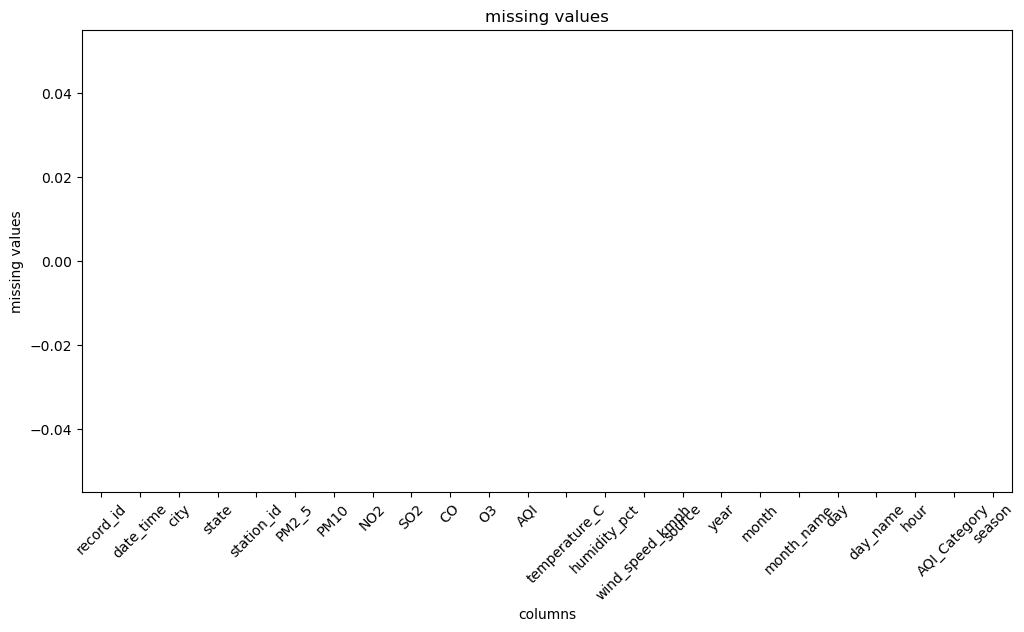

In [113]:
plt.figure(figsize=(12,6))
df.isnull().sum().plot(kind="bar")
plt.title("missing values")
plt.xlabel("columns")
plt.ylabel("missing values")
plt.xticks(rotation=45)
plt.show()

In [15]:
df.duplicated().sum()

np.int64(15)

In [16]:
# to see dupli rows :  
df[df.duplicated()]

,record_id,date_time,city,state,station_id,PM2_5,PM10,NO2,SO2,CO,O3,AQI,temperature_C,humidity_pct,wind_speed_kmph,source
9985,2180,2024-08-22 22:00:00,Jaipur,Rajasthan,IN-JAI-08,30.26,44.56,16.44,7.39,0.972,56.17,67.0,35.1,47.3,4.2,CPCB
9986,6311,2023-02-07 04:00:00,Jaipur,Rajasthan,IN-JAI-07,51.61,70.11,34.83,7.27,0.471,15.26,56.0,36.6,59.8,1.4,State Board
9987,2917,2025-01-17 01:00:00,Chandigarh,Chandigarh,IN-CHA-08,20.52,36.23,1.90,12.93,1.905,13.36,10.0,30.5,52.7,0.2,State Board
9988,4703,2025-07-10 00:00:00,Patna,Bihar,IN-PAT-02,149.39,NaN,NaN,4.90,0.336,43.59,160.0,29.2,NaN,8.2,State Board
9989,7613,2024-09-19 16:00:00,Jaipur,Rajasthan,IN-JAI-05,37.12,109.07,36.74,5.63,0.629,111.31,97.0,33.3,55.1,0.8,Research Sensor
9990,2611,2025-12-15 11:00:00,Varanasi,Uttar Pradesh,IN-VAR-08,126.74,212.01,13.88,1.74,0.631,89.64,128.0,21.7,82.7,2.6,CPCB
9991,5869,2025-10-28 10:00:00,Indore,Madhya Pradesh,IN-IND-04,32.05,43.29,43.56,6.24,0.937,11.88,18.0,29.8,73.6,4.2,CPCB
9992,1642,2025-05-17 20:00:00,Mumbai,Maharashtra,IN-MUM-02,28.74,72.10,NaN,NaN,0.425,1.00,54.0,21.1,67.6,2.4,CPCB
9993,5686,2023-01-19 22:00:00,Lucknow,Uttar Pradesh,IN-LUC-02,109.06,277.66,47.78,11.74,1.102,2.80,132.0,32.6,63.8,1.5,State Board
9994,6931,2024-07-31 07:00:00,Mumbai,Maharashtra,IN-MUM-05,40.71,71.13,28.72,10.79,0.848,1.84,83.0,31.4,73.6,3.1,Research Sensor


In [114]:
df=df.drop_duplicates()

In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
df.columns

Index(['record_id', 'date_time', 'city', 'state', 'station_id', 'PM2_5',
       'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'temperature_C',
       'humidity_pct', 'wind_speed_kmph', 'source', 'year', 'month',
       'month_name', 'day', 'day_name', 'hour', 'AQI_Category', 'season'],
      dtype='object')

In [20]:
# check invalid values :  
pollutants = ["PM2_5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"]
df[pollutants].describe()

,PM2_5,PM10,NO2,SO2,CO,O3,AQI
count,9960.000000,9960.000000,9960.000000,9960.000000,9960.000000,9960.000000,9960.000000
mean,69.074669,135.671882,25.525633,8.969988,0.737515,36.301958,89.086044
std,55.999099,101.230031,19.601572,6.869541,0.544373,26.697802,52.169937
min,3.000000,5.000000,1.000000,0.500000,0.050000,1.000000,10.000000
25%,31.072500,63.027500,11.507500,3.920000,0.340000,16.660000,53.000000
50%,55.390000,110.325000,21.265000,7.440000,0.603000,30.655000,79.000000
75%,91.902500,178.517500,34.660000,12.370000,0.988000,49.922500,115.000000
max,868.080000,600.000000,181.740000,65.010000,5.534000,214.540000,488.000000


In [21]:
df.isnull().sum()

record_id           0
date_time           0
city                0
state               0
station_id          0
PM2_5              25
PM10               25
NO2                25
SO2                25
CO                 25
O3                 25
AQI                25
temperature_C       0
humidity_pct       24
wind_speed_kmph     0
source              0
dtype: int64

In [22]:
(df[pollutants]<0).sum()

PM2_5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
AQI      0
dtype: int64

In [23]:
df["humidity_pct"].describe()

count    9961.000000
mean       58.416484
std        18.767678
min         8.000000
25%        45.700000
50%        58.400000
75%        71.600000
max       128.900000
Name: humidity_pct, dtype: float64

In [24]:
(df["humidity_pct"]>100)

0       False
1       False
2       False
3       False
4       False
        ...  
9980    False
9981    False
9982    False
9983    False
9984    False
Name: humidity_pct, Length: 9985, dtype: bool

In [25]:
df["wind_speed_kmph"].describe()

count    9985.000000
mean        4.020781
std         3.110115
min         0.000000
25%         1.900000
50%         3.400000
75%         5.400000
max        64.900000
Name: wind_speed_kmph, dtype: float64

In [26]:
numeric_columns= [
    "PM2_5",
       "PM10", "NO2", "SO2", "CO", "O3", "AQI", "temperature_C",
       "humidity_pct", "wind_speed_kmph"
]
for col in numeric_columns: 
    df[col]=df[col].fillna(df[col].median())

In [27]:
df.isnull().sum()

record_id          0
date_time          0
city               0
state              0
station_id         0
PM2_5              0
PM10               0
NO2                0
SO2                0
CO                 0
O3                 0
AQI                0
temperature_C      0
humidity_pct       0
wind_speed_kmph    0
source             0
dtype: int64

In [28]:
df["year"]=df["date_time"].dt.year

In [29]:
df["month"]=df["date_time"].dt.month

In [30]:
df["month_name"]=df["date_time"].dt.month_name

In [31]:
df["day"]=df["date_time"].dt.day

In [32]:
df["day_name"]=df["date_time"].dt.day_name

In [33]:
df.columns

Index(['record_id', 'date_time', 'city', 'state', 'station_id', 'PM2_5',
       'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'temperature_C',
       'humidity_pct', 'wind_speed_kmph', 'source', 'year', 'month',
       'month_name', 'day', 'day_name'],
      dtype='object')

In [34]:
df["hour"]=df["date_time"].dt.hour

In [35]:
def aqi_category(aqi): 
    if aqi<= 50:
        return "good"
    elif aqi<=100:  
        return "satisfactory"
    elif aqi<=200:  
        return "moderate"
    elif aqi<=300: 
        return "poor"
    elif aqi<=400:  
        return "very poor"
    else: 
        return "Business"

In [36]:
df["AQI_Category"] = df["AQI"].apply(aqi_category)

In [37]:
df["AQI_Category"].value_counts()

AQI_Category
satisfactory    4318
moderate        2974
good            2315
poor             339
very poor         37
Business           2
Name: count, dtype: int64

In [38]:
df.columns

Index(['record_id', 'date_time', 'city', 'state', 'station_id', 'PM2_5',
       'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'temperature_C',
       'humidity_pct', 'wind_speed_kmph', 'source', 'year', 'month',
       'month_name', 'day', 'day_name', 'hour', 'AQI_Category'],
      dtype='object')

In [39]:
def get_season(month): 
    if month in [12,1,2]: 
        return "winter"
    elif month in [3,4,5]:
        return "summer"
    elif month in [6,7,8]:
        return "monsoon"
    else: 
        return "post_monsoon"

In [40]:
df["season"]=df["month"].apply(get_season)

In [41]:
df["season"].value_counts()

season
winter          2575
summer          2509
post_monsoon    2478
monsoon         2423
Name: count, dtype: int64

In [42]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9985 entries, 0 to 9984
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   record_id        9985 non-null   int64         
 1   date_time        9985 non-null   datetime64[ns]
 2   city             9985 non-null   object        
 3   state            9985 non-null   object        
 4   station_id       9985 non-null   object        
 5   PM2_5            9985 non-null   float64       
 6   PM10             9985 non-null   float64       
 7   NO2              9985 non-null   float64       
 8   SO2              9985 non-null   float64       
 9   CO               9985 non-null   float64       
 10  O3               9985 non-null   float64       
 11  AQI              9985 non-null   float64       
 12  temperature_C    9985 non-null   float64       
 13  humidity_pct     9985 non-null   float64       
 14  wind_speed_kmph  9985 non-null   float64     

In [43]:
df.isnull().sum()

record_id          0
date_time          0
city               0
state              0
station_id         0
PM2_5              0
PM10               0
NO2                0
SO2                0
CO                 0
O3                 0
AQI                0
temperature_C      0
humidity_pct       0
wind_speed_kmph    0
source             0
year               0
month              0
month_name         0
day                0
day_name           0
hour               0
AQI_Category       0
season             0
dtype: int64

In [44]:
df.describe()

,record_id,date_time,PM2_5,PM10,NO2,SO2,CO,O3,AQI,temperature_C,humidity_pct,wind_speed_kmph,year,month,day,hour
count,9985.000000,9985,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000,9985.000000
mean,4993.000000,2024-06-28 19:51:43.174762240,69.040406,135.608419,25.514965,8.966157,0.737178,36.287819,89.060791,28.094912,58.416445,4.020781,2023.994692,6.481022,15.753030,11.588783
min,1.000000,2023-01-01 08:00:00,3.000000,5.000000,1.000000,0.500000,0.050000,1.000000,10.000000,3.000000,8.000000,0.000000,2023.000000,1.000000,1.000000,0.000000
25%,2497.000000,2023-09-30 13:00:00,31.140000,63.090000,11.540000,3.930000,0.340000,16.690000,53.000000,23.400000,45.700000,1.900000,2023.000000,3.000000,8.000000,6.000000
50%,4993.000000,2024-07-01 22:00:00,55.390000,110.325000,21.265000,7.440000,0.603000,30.655000,79.000000,28.000000,58.400000,3.400000,2024.000000,7.000000,16.000000,12.000000
75%,7489.000000,2025-03-26 06:00:00,91.770000,178.120000,34.590000,12.340000,0.987000,49.820000,115.000000,32.700000,71.500000,5.400000,2025.000000,10.000000,23.000000,18.000000
max,9985.000000,2025-12-31 23:00:00,868.080000,600.000000,181.740000,65.010000,5.534000,214.540000,488.000000,48.000000,128.900000,64.900000,2025.000000,12.000000,31.000000,23.000000
std,2882.565553,NaN,55.933125,101.111147,19.578173,6.861361,0.543733,26.665849,52.107017,6.895253,18.745108,3.110115,0.813714,3.491930,8.813182,6.867956


In [45]:
df.to_csv("air_quality",index=False)  

In [46]:
print("count of unoque city",df["city"].nunique())
print("count of unoque state",df["state"].nunique())


count of unoque city 20
count of unoque state 15


In [47]:
df["AQI"].max()

488.0

In [48]:
# city wise aqi 
city_aqi=df.groupby("city")["AQI"].mean().sort_values(ascending=False)
print("city wise aqi :",city_aqi)

city wise aqi : city
Delhi            125.401247
Kanpur           108.721414
Lucknow          104.934823
Patna            104.516605
Varanasi         104.077244
Ahmedabad         96.885321
Jaipur            91.388560
Kolkata           89.531373
Visakhapatnam     88.961847
Indore            85.836000
Hyderabad         84.578450
Guwahati          83.433594
Pune              83.375940
Bhopal            83.347023
Chandigarh        82.695096
Nagpur            82.309623
Mumbai            81.590361
Chennai           75.524462
Bengaluru         63.530214
Kochi             61.855670
Name: AQI, dtype: float64


In [49]:
city_aqi.head(10)

city
Delhi            125.401247
Kanpur           108.721414
Lucknow          104.934823
Patna            104.516605
Varanasi         104.077244
Ahmedabad         96.885321
Jaipur            91.388560
Kolkata           89.531373
Visakhapatnam     88.961847
Indore            85.836000
Name: AQI, dtype: float64

In [50]:
city_aqi.tail(10)

city
Hyderabad     84.578450
Guwahati      83.433594
Pune          83.375940
Bhopal        83.347023
Chandigarh    82.695096
Nagpur        82.309623
Mumbai        81.590361
Chennai       75.524462
Bengaluru     63.530214
Kochi         61.855670
Name: AQI, dtype: float64

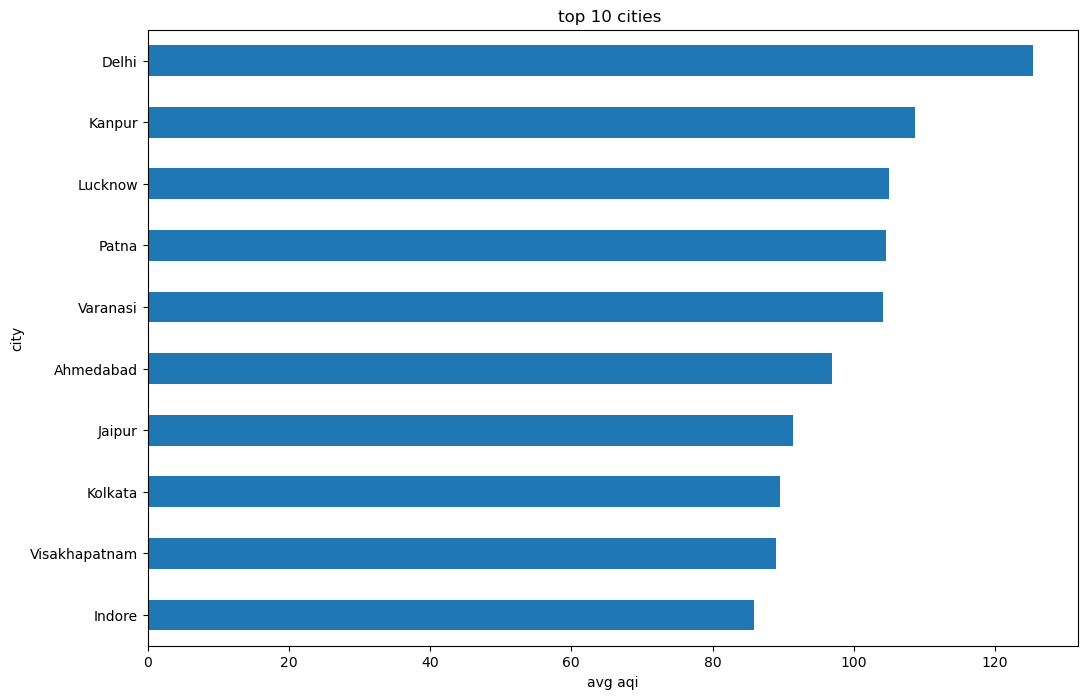

In [51]:
# TOP 10 City-wise AQI Plot
plt.figure(figsize=(12,8)) 
city_aqi.head(10).sort_values().plot(kind="barh")
plt.title("top 10 cities ")
plt.xlabel("avg aqi")
plt.ylabel("city")
plt.show()

In [52]:
state_aqi=df.groupby("state")["AQI"].mean().sort_values(ascending=False)
state_aqi

state
Delhi             125.401247
Uttar Pradesh     105.877088
Bihar             104.516605
Gujarat            96.885321
Rajasthan          91.388560
West Bengal        89.531373
Andhra Pradesh     88.961847
Madhya Pradesh     84.607903
Telangana          84.578450
Assam              83.433594
Chandigarh         82.695096
Maharashtra        82.448276
Tamil Nadu         75.524462
Karnataka          63.530214
Kerala             61.855670
Name: AQI, dtype: float64

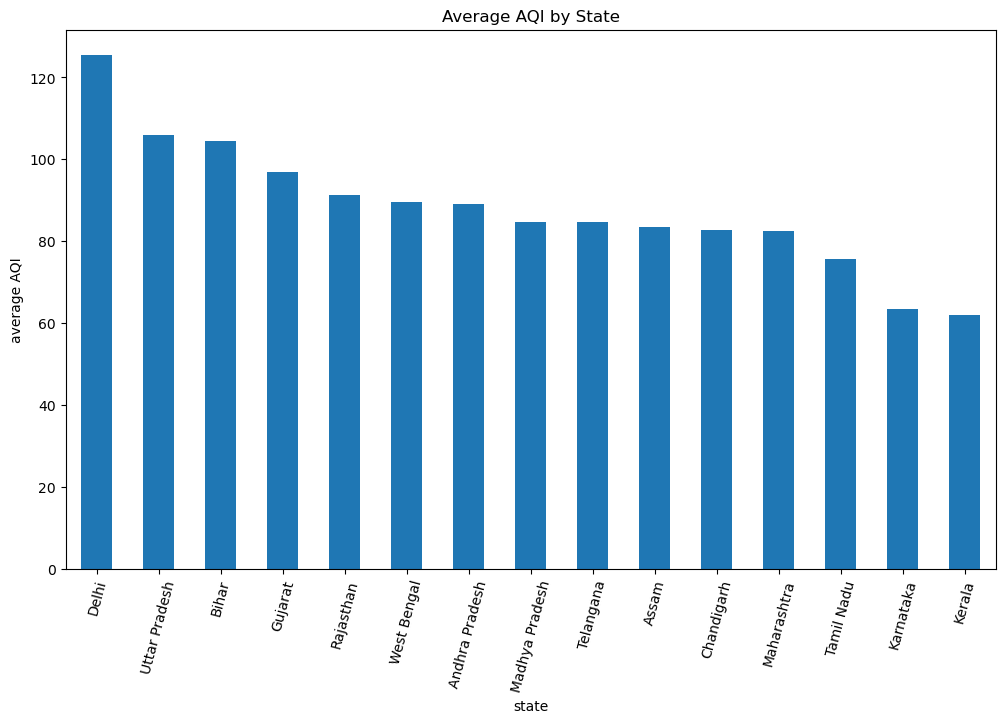

In [57]:
plt.figure(figsize=(12,7))
state_aqi.plot(kind="bar")
plt.title("Average AQI by State")
plt.xlabel("state") 
plt.ylabel("average AQI")
plt.xticks(rotation=75)
plt.show()

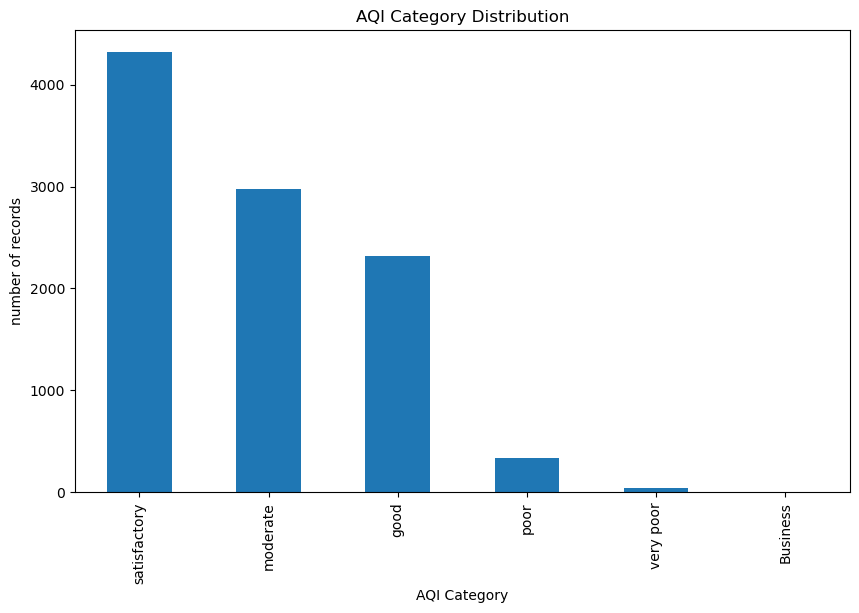

In [59]:
# AQI Category Analysis  
plt.figure(figsize=(10,6))
df["AQI_Category"].value_counts().plot(kind="bar")
plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("number of records")
plt.show()

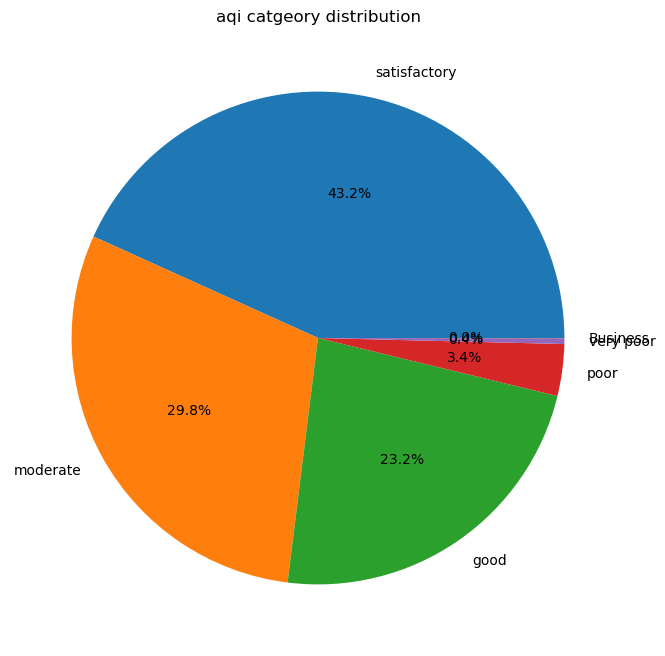

In [61]:
plt.figure(figsize=(8,8))
df["AQI_Category"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("aqi catgeory distribution")
plt.ylabel("")
plt.show()

In [63]:
# Pollutant Analysis 
df["PM2_5"].describe()

count    9985.000000
mean       69.040406
std        55.933125
min         3.000000
25%        31.140000
50%        55.390000
75%        91.770000
max       868.080000
Name: PM2_5, dtype: float64

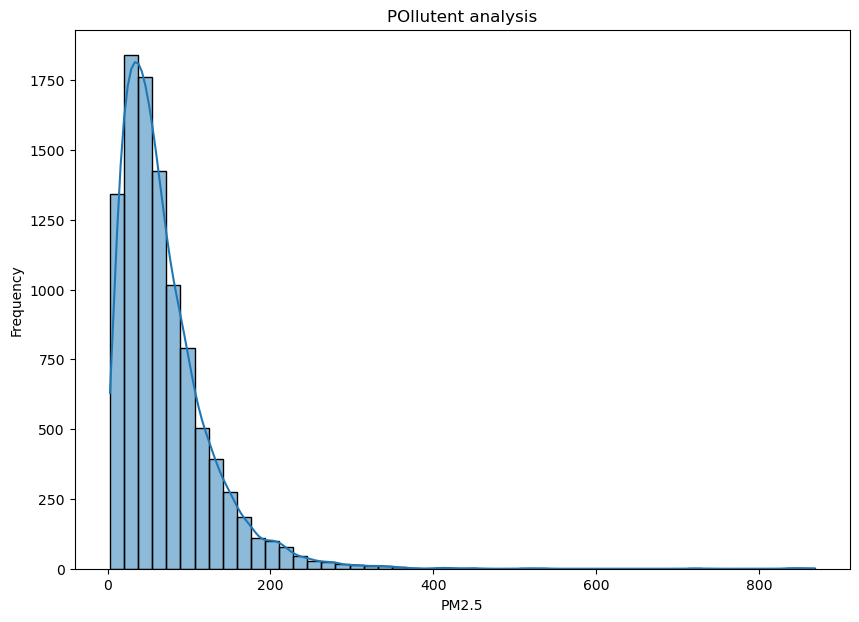

In [65]:
plt.figure(figsize=(10,7))
sns.histplot(df["PM2_5"],bins=50,kde=True)
plt.title("POllutent analysis")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

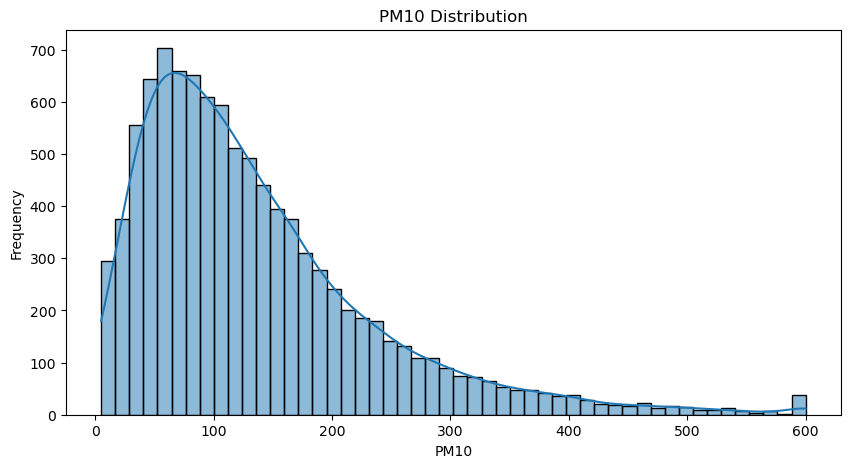

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(df["PM10"],bins=50,kde=True)
plt.title("PM10 Distribution")
plt.xlabel("PM10")
plt.ylabel("Frequency")
plt.show()

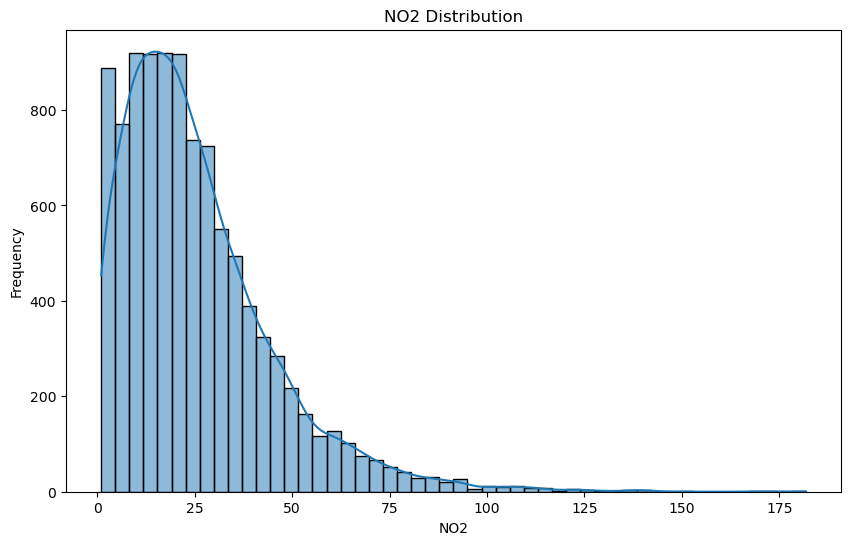

In [68]:
plt.figure(figsize=(10, 6))

sns.histplot(df["NO2"], bins=50, kde=True)

plt.title("NO2 Distribution")
plt.xlabel("NO2")
plt.ylabel("Frequency")

plt.show()

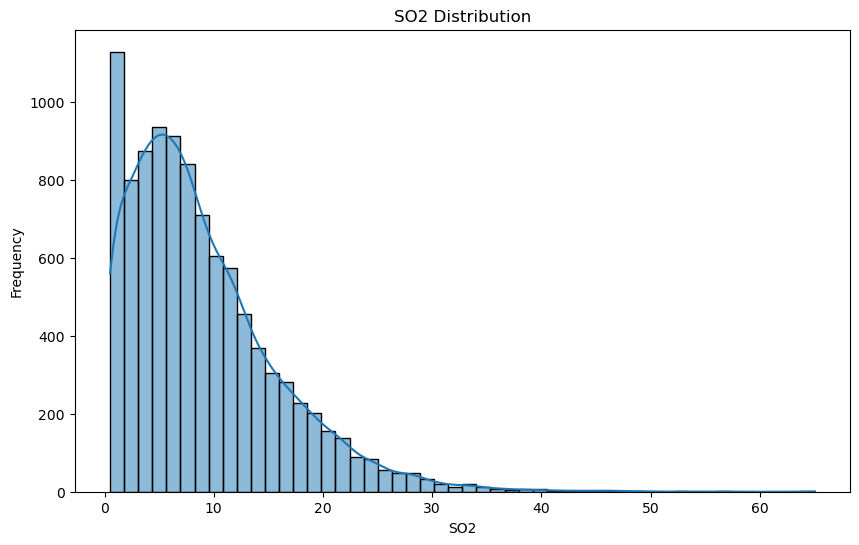

In [69]:
plt.figure(figsize=(10, 6))

sns.histplot(df["SO2"], bins=50, kde=True)

plt.title("SO2 Distribution")
plt.xlabel("SO2")
plt.ylabel("Frequency")

plt.show()

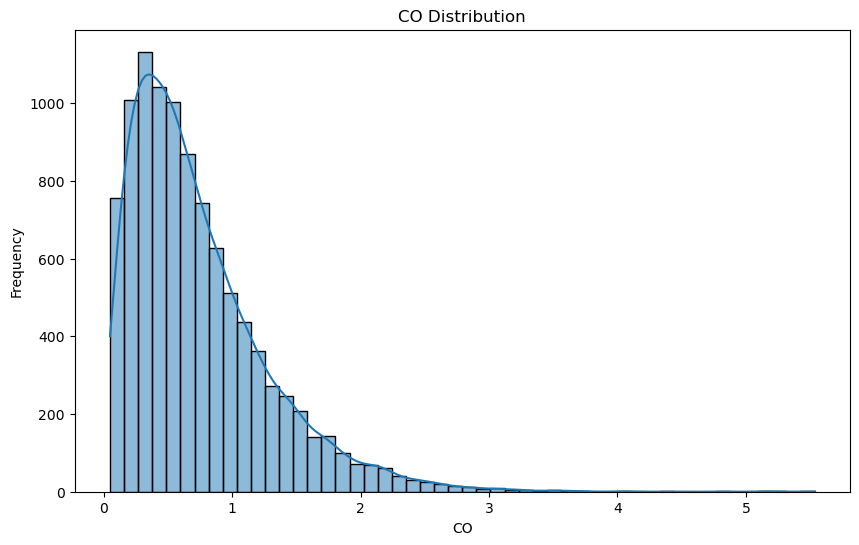

In [70]:
plt.figure(figsize=(10, 6))

sns.histplot(df["CO"], bins=50, kde=True)

plt.title("CO Distribution")
plt.xlabel("CO")
plt.ylabel("Frequency")

plt.show()

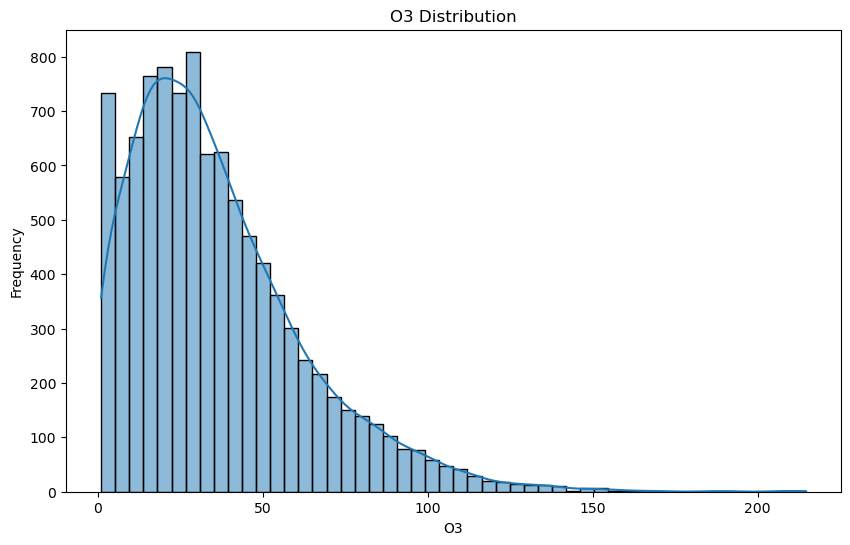

In [71]:
plt.figure(figsize=(10, 6))

sns.histplot(df["O3"], bins=50, kde=True)

plt.title("O3 Distribution")
plt.xlabel("O3")
plt.ylabel("Frequency")

plt.show()

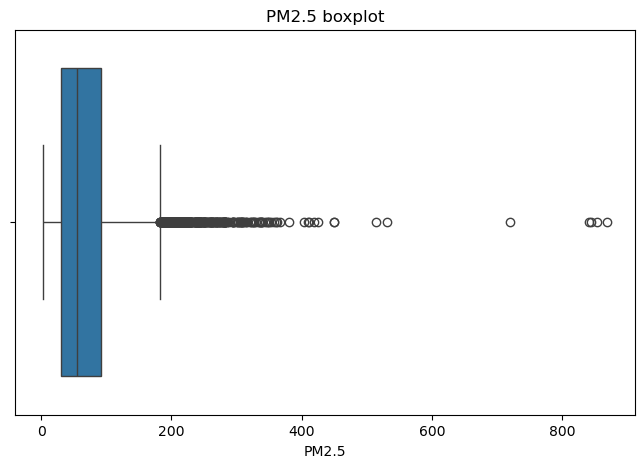

In [72]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["PM2_5"])
plt.title("PM2.5 boxplot")
plt.xlabel("PM2.5")
plt.show()

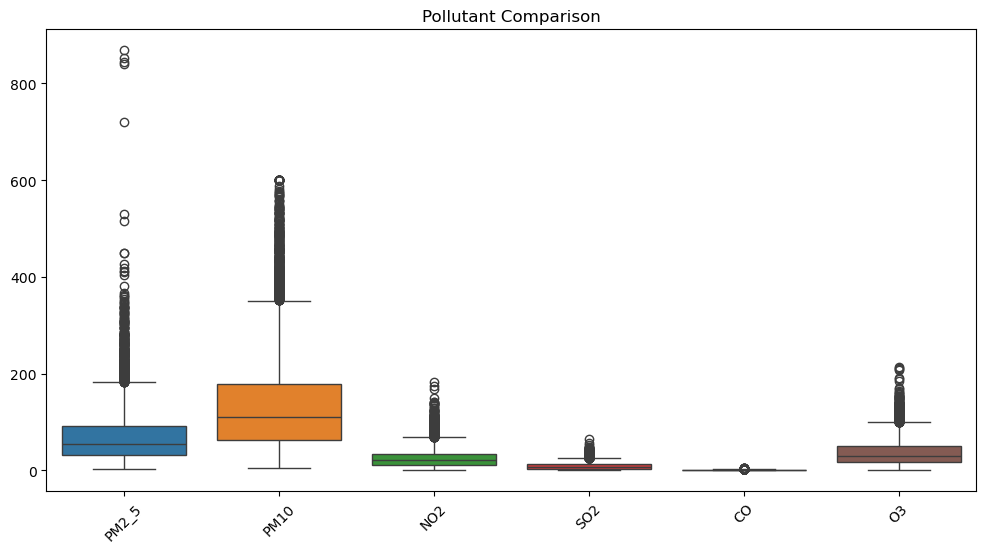

In [73]:
plt.figure(figsize=(12, 6)) 
sns.boxplot(
    data=df[["PM2_5", "PM10", "NO2", "SO2", "CO", "O3"]]
)
plt.title("Pollutant Comparison")
plt.xticks(rotation=45)

plt.show()   

In [74]:
# Monthly AQI Trend  
monthly_aqi=df.groupby("month")["AQI"].mean()
monthly_aqi

month
1      99.489526
2     103.556522
3      82.880137
4      81.203026
5      81.008333
6      78.214667
7      81.697842
8      81.263409
9      80.578554
10     99.164352
11     99.152709
12     98.304751
Name: AQI, dtype: float64

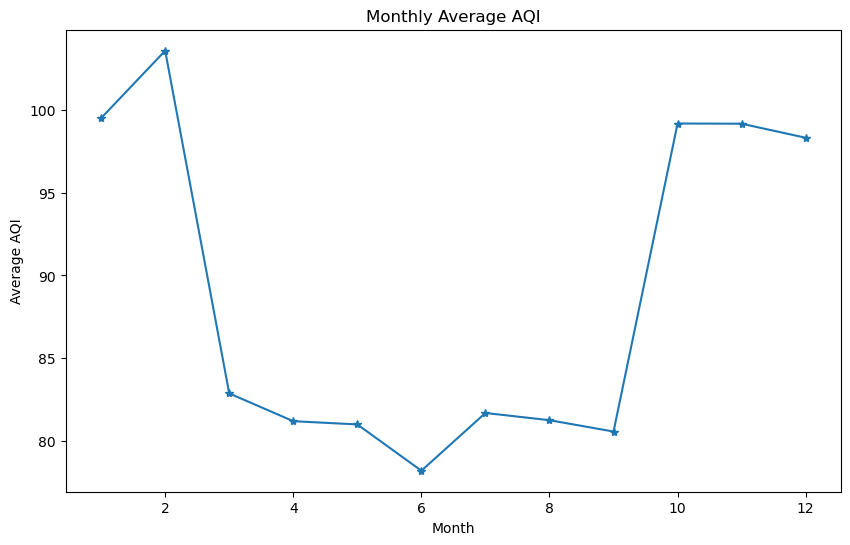

In [75]:
plt.figure(figsize=(10, 6))   
plt.plot(
    monthly_aqi.index,
    monthly_aqi.values,
    marker="*"
)
plt.title("Monthly Average AQI")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()   


In [76]:
yearly_aqi=df.groupby("year")["AQI"].mean()  
yearly_aqi

year
2023    90.583133
2024    87.653823
2025    88.961574
Name: AQI, dtype: float64

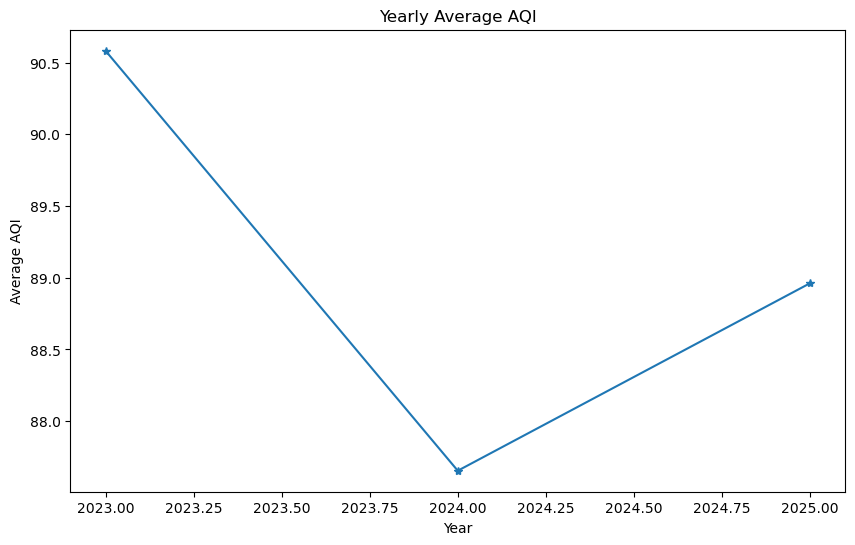

In [77]:
plt.figure(figsize=(10, 6))    
plt.plot(
    yearly_aqi.index, 
    yearly_aqi.values, 
    marker="*"
    )
plt.title("Yearly Average AQI")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.show()

In [78]:
# Seasonal Analysis 
season_aqi = df.groupby("season")["AQI"].mean()
season_aqi

season
monsoon          80.469253
post_monsoon     93.145278
summer           81.723396
winter          100.363883
Name: AQI, dtype: float64

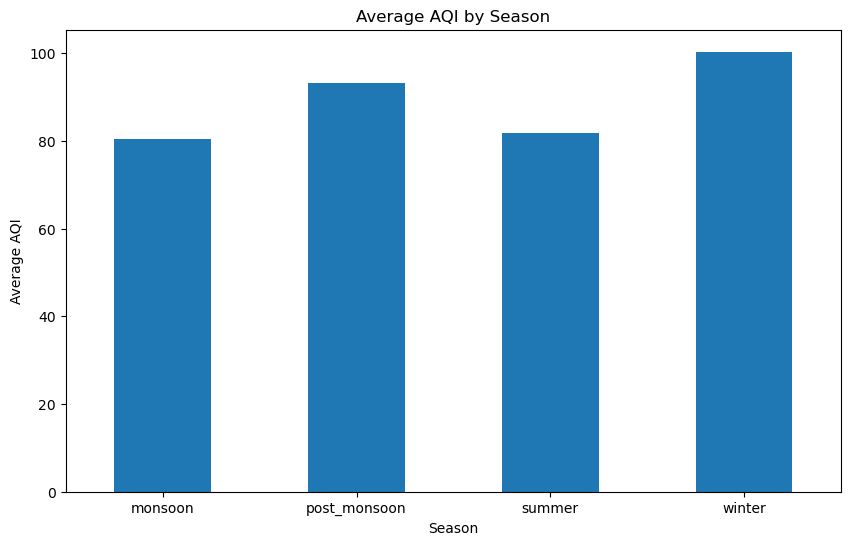

In [79]:
plt.figure(figsize=(10, 6))

season_aqi.plot(kind="bar")

plt.title("Average AQI by Season")
plt.xlabel("Season")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)

plt.show()

In [84]:
# AQI by Day of Week  
day_aqi = df.groupby("day_name")["AQI"].mean()
day_aqi

day_name
<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x000002620E864C20>>    89.060791
Name: AQI, dtype: float64

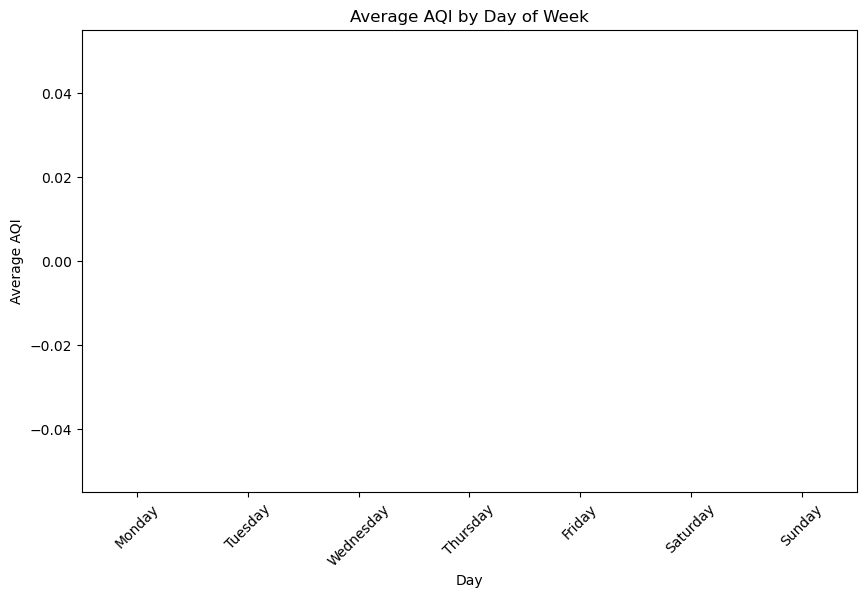

In [83]:
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_aqi = day_aqi.reindex(days)

plt.figure(figsize=(10, 6))

day_aqi.plot(kind="bar")

plt.title("Average AQI by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)

plt.show()

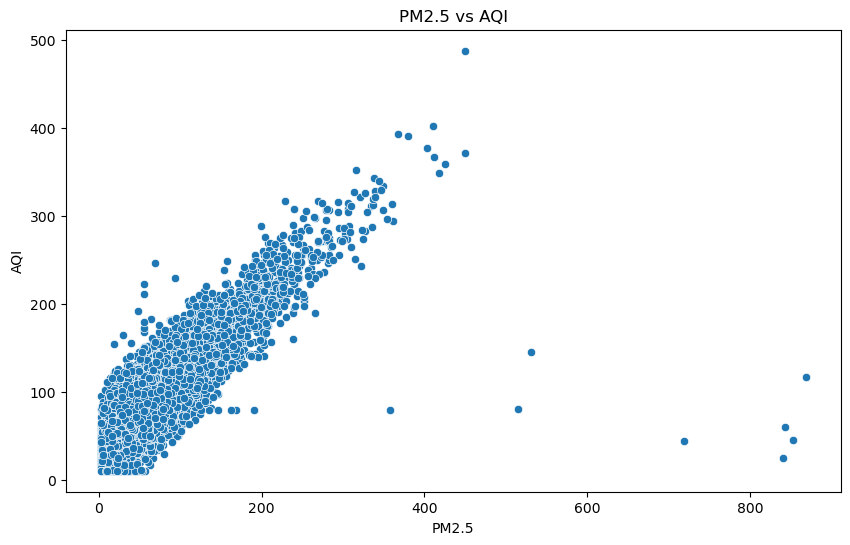

In [85]:
# Pollutant vs AQI  
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="PM2_5",
    y="AQI"
)

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.show()

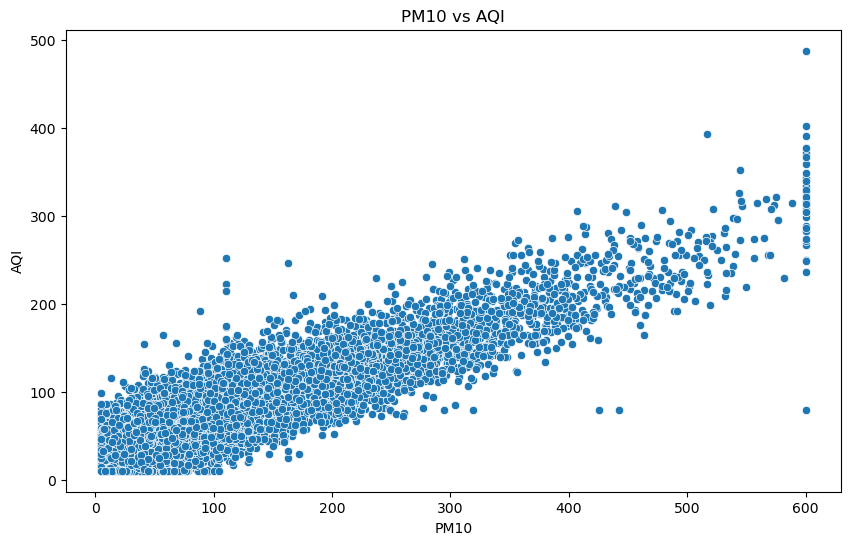

In [86]:
# PM10 vs AQI  
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="PM10",
    y="AQI"
)

plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")

plt.show()

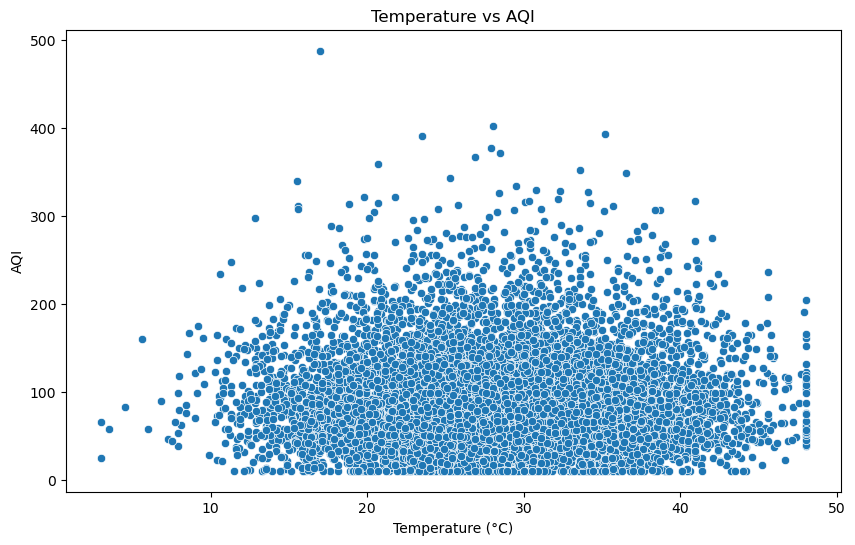

In [87]:
# Temperature vs AQI  
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temperature_C",
    y="AQI"
)

plt.title("Temperature vs AQI")
plt.xlabel("Temperature (°C)")
plt.ylabel("AQI")

plt.show()   

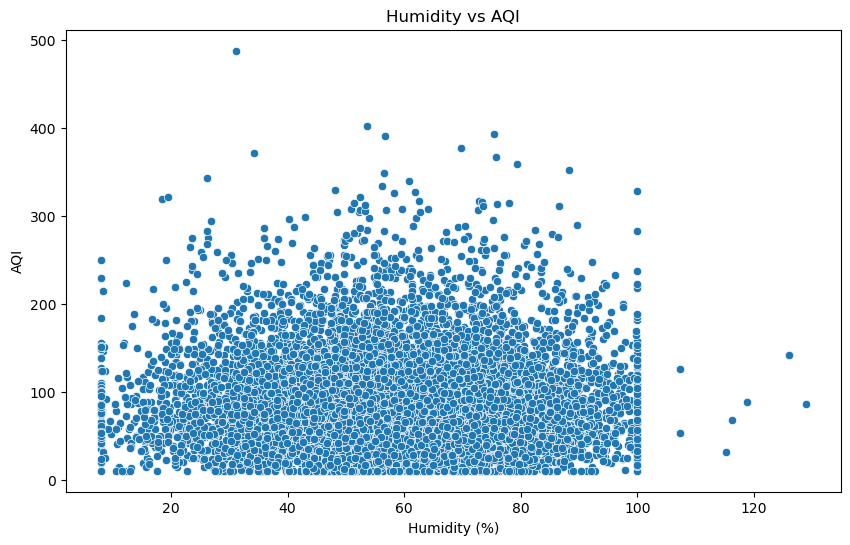

In [88]:
# Humidity vs AQI  
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="humidity_pct",
    y="AQI"
)

plt.title("Humidity vs AQI")
plt.xlabel("Humidity (%)")
plt.ylabel("AQI")

plt.show() 

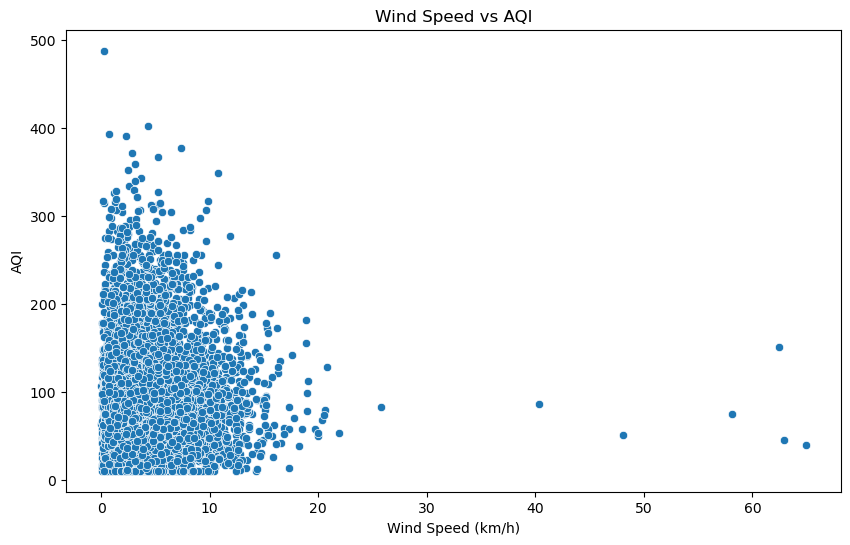

In [89]:
# Wind Speed vs AQI 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="wind_speed_kmph",
    y="AQI"
)

plt.title("Wind Speed vs AQI")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("AQI")

plt.show()  

In [90]:
# Correlation Analysis 
numeric_df = df[
    [
        "PM2_5",
        "PM10",
        "NO2",
        "SO2",
        "CO",
        "O3",
        "AQI",
        "temperature_C",
        "humidity_pct",
        "wind_speed_kmph"
    ]
]

In [91]:
correlation = numeric_df.corr()

correlation

,PM2_5,PM10,NO2,SO2,CO,O3,AQI,temperature_C,humidity_pct,wind_speed_kmph
PM2_5,1.000000,0.884161,0.044435,-0.004489,0.053932,0.002234,0.837174,-0.009372,0.005348,0.004449
PM10,0.884161,1.000000,0.046241,-0.010110,0.055363,0.001612,0.875966,0.000932,-0.003605,0.010629
NO2,0.044435,0.046241,1.000000,-0.018750,0.043838,-0.008213,0.292121,0.003535,0.014804,-0.014060
SO2,-0.004489,-0.010110,-0.018750,1.000000,-0.014705,-0.005321,-0.009607,0.001510,-0.007673,-0.004129
CO,0.053932,0.055363,0.043838,-0.014705,1.000000,0.006617,0.104068,-0.001867,-0.006479,-0.011214
O3,0.002234,0.001612,-0.008213,-0.005321,0.006617,1.000000,0.105665,-0.000593,-0.001354,-0.006143
AQI,0.837174,0.875966,0.292121,-0.009607,0.104068,0.105665,1.000000,-0.001914,0.002279,-0.002096
temperature_C,-0.009372,0.000932,0.003535,0.001510,-0.001867,-0.000593,-0.001914,1.000000,-0.000249,-0.008338
humidity_pct,0.005348,-0.003605,0.014804,-0.007673,-0.006479,-0.001354,0.002279,-0.000249,1.000000,0.013932
wind_speed_kmph,0.004449,0.010629,-0.014060,-0.004129,-0.011214,-0.006143,-0.002096,-0.008338,0.013932,1.000000


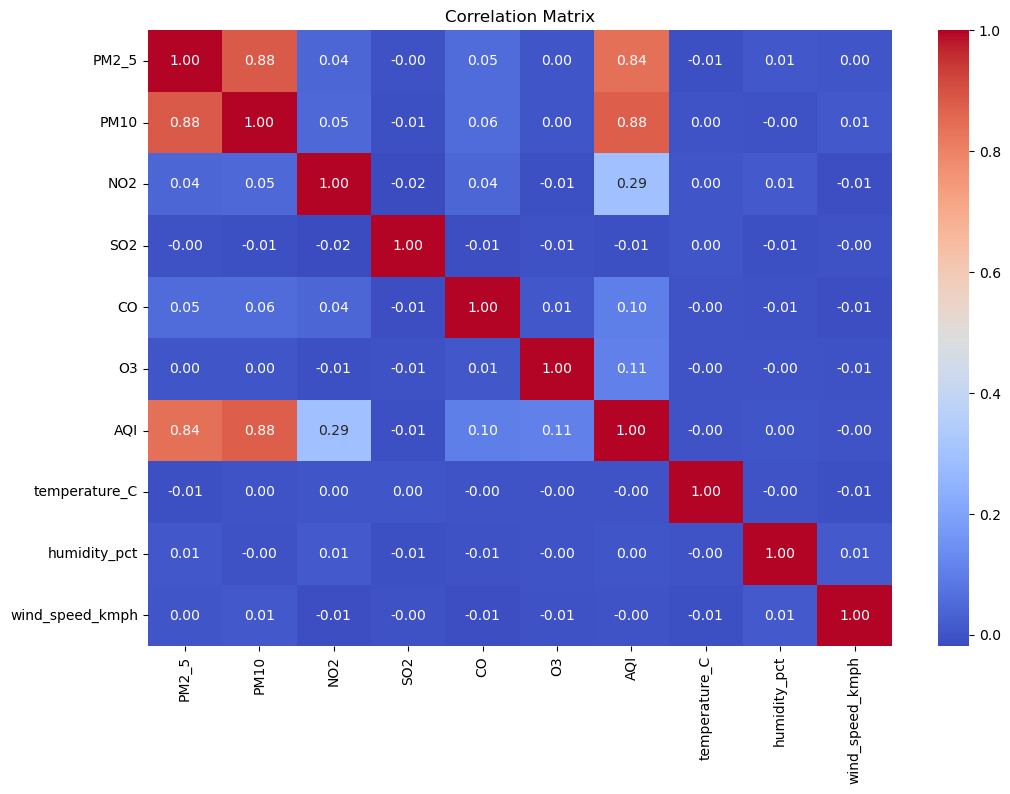

In [92]:
plt.figure(figsize=(12, 8))  
sns.heatmap (
    correlation, 
    annot=True,  
     cmap="coolwarm",
    fmt=".2f" 
)
plt.title("Correlation Matrix")

plt.show()

In [93]:
# strongest aqi :  

correlation["AQI"].sort_values(ascending=False)

AQI                1.000000
PM10               0.875966
PM2_5              0.837174
NO2                0.292121
O3                 0.105665
CO                 0.104068
humidity_pct       0.002279
temperature_C     -0.001914
wind_speed_kmph   -0.002096
SO2               -0.009607
Name: AQI, dtype: float64

In [94]:
# City + AQI Category 
city_category = pd.crosstab(
    df["city"],
    df["AQI_Category"]
)

city_category

AQI_Category,Business,good,moderate,poor,satisfactory,very poor
city,,,,,,
Ahmedabad,0,82,143,26,183,2
Bengaluru,0,209,71,2,231,0
Bhopal,0,124,127,15,220,1
Chandigarh,0,124,133,10,202,0
Chennai,0,150,110,8,243,0
Delhi,2,52,218,54,148,7
Guwahati,0,128,146,7,231,0
Hyderabad,0,125,147,16,241,0
Indore,0,117,161,6,214,2


In [95]:
# Worst AQI Records 
df.sort_values(
    by="AQI",
    ascending=False
).head(20)

,record_id,date_time,city,state,station_id,PM2_5,PM10,NO2,SO2,CO,...,wind_speed_kmph,source,year,month,month_name,day,day_name,hour,AQI_Category,season
4054,4055,2025-12-12 02:00:00,Delhi,Delhi,IN-DEL-05,450.00,600.00,139.34,0.50,2.106,...,0.3,CPCB,2025,12,<bound method PandasDelegate._add_delegate_acc...,12,<bound method PandasDelegate._add_delegate_acc...,2,Business,winter
6564,6565,2023-12-13 12:00:00,Delhi,Delhi,IN-DEL-05,410.37,600.00,86.18,4.52,1.228,...,4.3,State Board,2023,12,<bound method PandasDelegate._add_delegate_acc...,13,<bound method PandasDelegate._add_delegate_acc...,12,Business,winter
8538,8539,2025-10-14 03:00:00,Delhi,Delhi,IN-DEL-03,367.21,516.91,111.97,0.98,2.160,...,0.7,State Board,2025,10,<bound method PandasDelegate._add_delegate_acc...,14,<bound method PandasDelegate._add_delegate_acc...,3,very poor,post_monsoon
1742,1743,2023-12-08 11:00:00,Jaipur,Rajasthan,IN-JAI-05,380.29,600.00,66.43,5.68,1.855,...,2.3,CPCB,2023,12,<bound method PandasDelegate._add_delegate_acc...,8,<bound method PandasDelegate._add_delegate_acc...,11,very poor,winter
4626,4627,2024-12-22 03:00:00,Delhi,Delhi,IN-DEL-02,402.94,600.00,39.12,15.71,0.542,...,7.4,CPCB,2024,12,<bound method PandasDelegate._add_delegate_acc...,22,<bound method PandasDelegate._add_delegate_acc...,3,very poor,winter
889,890,2023-03-12 03:00:00,Kolkata,West Bengal,IN-KOL-07,450.00,600.00,8.70,6.43,0.793,...,2.8,CPCB,2023,3,<bound method PandasDelegate._add_delegate_acc...,12,<bound method PandasDelegate._add_delegate_acc...,3,very poor,summer
5079,5080,2023-03-22 14:00:00,Patna,Bihar,IN-PAT-06,411.75,600.00,14.66,6.82,2.355,...,5.2,CPCB,2023,3,<bound method PandasDelegate._add_delegate_acc...,22,<bound method PandasDelegate._add_delegate_acc...,14,very poor,summer
1391,1392,2024-12-29 23:00:00,Patna,Bihar,IN-PAT-05,425.59,600.00,49.36,1.20,0.826,...,3.1,CPCB,2024,12,<bound method PandasDelegate._add_delegate_acc...,29,<bound method PandasDelegate._add_delegate_acc...,23,very poor,winter
4126,4127,2023-10-05 21:00:00,Delhi,Delhi,IN-DEL-02,316.49,544.14,55.97,1.33,1.393,...,2.5,CPCB,2023,10,<bound method PandasDelegate._add_delegate_acc...,5,<bound method PandasDelegate._add_delegate_acc...,21,very poor,post_monsoon
3764,3765,2024-10-21 15:00:00,Lucknow,Uttar Pradesh,IN-LUC-04,418.34,600.00,16.31,27.56,0.313,...,10.8,CPCB,2024,10,<bound method PandasDelegate._add_delegate_acc...,21,<bound method PandasDelegate._add_delegate_acc...,15,very poor,post_monsoon


In [96]:
# Best AQI Records 
df.sort_values(
    by="AQI",
    ascending=True
).head(20)

,record_id,date_time,city,state,station_id,PM2_5,PM10,NO2,SO2,CO,...,wind_speed_kmph,source,year,month,month_name,day,day_name,hour,AQI_Category,season
2125,2126,2023-05-15 11:00:00,Kolkata,West Bengal,IN-KOL-03,13.15,5.00,1.00,12.70,0.196,...,1.5,State Board,2023,5,<bound method PandasDelegate._add_delegate_acc...,15,<bound method PandasDelegate._add_delegate_acc...,11,good,summer
2126,2127,2024-07-27 17:00:00,Pune,Maharashtra,IN-PUN-02,9.46,16.36,8.63,9.59,0.762,...,4.4,Research Sensor,2024,7,<bound method PandasDelegate._add_delegate_acc...,27,<bound method PandasDelegate._add_delegate_acc...,17,good,monsoon
2364,2365,2023-02-18 09:00:00,Guwahati,Assam,IN-GUW-05,28.69,50.52,15.61,0.50,0.525,...,1.9,CPCB,2023,2,<bound method PandasDelegate._add_delegate_acc...,18,<bound method PandasDelegate._add_delegate_acc...,9,good,winter
5265,5266,2024-06-06 13:00:00,Nagpur,Maharashtra,IN-NAG-07,17.57,52.64,9.45,1.62,0.430,...,7.3,CPCB,2024,6,<bound method PandasDelegate._add_delegate_acc...,6,<bound method PandasDelegate._add_delegate_acc...,13,good,monsoon
8376,8377,2025-09-18 14:00:00,Hyderabad,Telangana,IN-HYD-05,33.32,32.29,3.43,3.01,0.337,...,6.6,CPCB,2025,9,<bound method PandasDelegate._add_delegate_acc...,18,<bound method PandasDelegate._add_delegate_acc...,14,good,post_monsoon
2480,2481,2024-04-15 14:00:00,Kochi,Kerala,IN-KOC-07,19.23,8.60,3.47,8.57,0.357,...,5.6,CPCB,2024,4,<bound method PandasDelegate._add_delegate_acc...,15,<bound method PandasDelegate._add_delegate_acc...,14,good,summer
756,757,2025-05-08 14:00:00,Visakhapatnam,Andhra Pradesh,IN-VIS-05,30.54,63.11,22.37,2.30,0.872,...,4.0,CPCB,2025,5,<bound method PandasDelegate._add_delegate_acc...,8,<bound method PandasDelegate._add_delegate_acc...,14,good,summer
8580,8581,2023-02-26 07:00:00,Hyderabad,Telangana,IN-HYD-06,3.19,5.00,3.46,0.96,1.171,...,1.0,State Board,2023,2,<bound method PandasDelegate._add_delegate_acc...,26,<bound method PandasDelegate._add_delegate_acc...,7,good,winter
7781,7782,2024-05-29 21:00:00,Bengaluru,Karnataka,IN-BEN-02,4.03,6.50,1.00,4.71,0.121,...,8.8,CPCB,2024,5,<bound method PandasDelegate._add_delegate_acc...,29,<bound method PandasDelegate._add_delegate_acc...,21,good,summer
2846,2847,2025-08-13 03:00:00,Nagpur,Maharashtra,IN-NAG-08,6.28,29.75,22.68,8.35,0.527,...,1.0,Low-cost Sensor,2025,8,<bound method PandasDelegate._add_delegate_acc...,13,<bound method PandasDelegate._add_delegate_acc...,3,good,monsoon


In [97]:
# Highest PM2.5 Cities 
pm25_city = df.groupby("city")["PM2_5"].mean().sort_values(ascending=False)

pm25_city.head(10) 

city
Delhi            97.600894
Kanpur           85.973514
Varanasi         83.220104
Lucknow          82.843575
Patna            82.832196
Ahmedabad        75.041927
Visakhapatnam    72.284378
Kolkata          70.874510
Jaipur           69.663570
Bhopal           66.699220
Name: PM2_5, dtype: float64

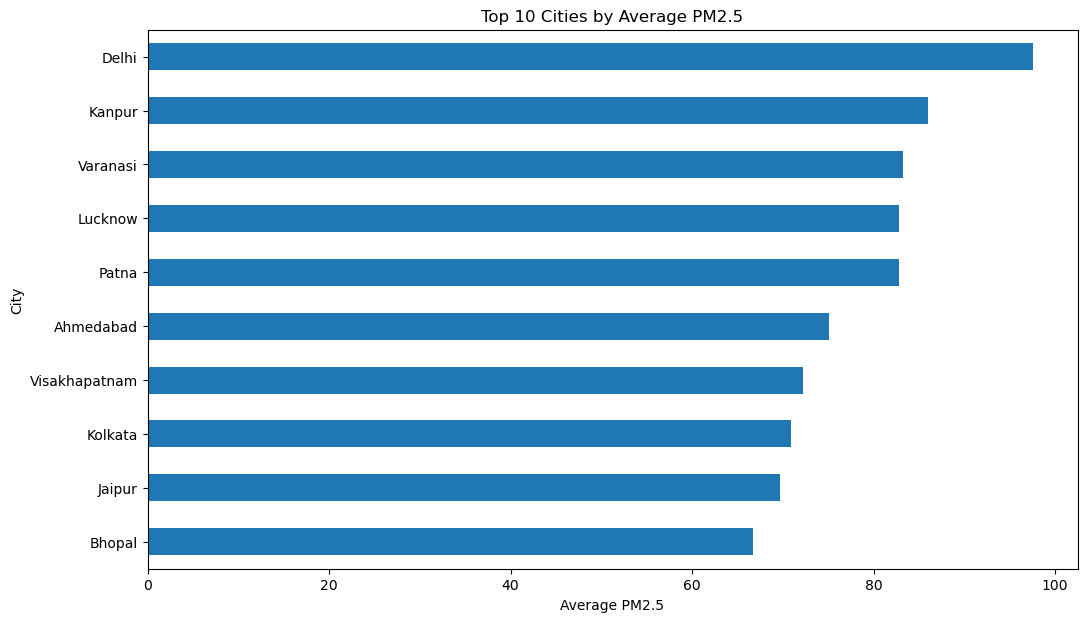

In [98]:
plt.figure(figsize=(12, 7))

pm25_city.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Average PM2.5")
plt.xlabel("Average PM2.5")
plt.ylabel("City")

plt.show()

In [99]:
# Highest PM10 Cities 
pm10_city = df.groupby("city")["PM10"].mean().sort_values(ascending=False)

pm10_city.head(10)

city
Delhi            187.115748
Kanpur           169.568493
Lucknow          161.659907
Patna            161.295627
Varanasi         159.928225
Ahmedabad        146.744450
Kolkata          140.771216
Jaipur           139.450513
Visakhapatnam    134.785552
Bhopal           129.582105
Name: PM10, dtype: float64

In [101]:
# Pollution by Season  
season_pollution = df.groupby("season")[
    ["PM2_5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"]
].mean()

season_pollution

,PM2_5,PM10,NO2,SO2,CO,O3,AQI
season,,,,,,,
monsoon,58.309798,117.598304,25.146319,8.918861,0.739567,36.539899,80.469253
post_monsoon,73.977454,144.192657,25.905048,8.966598,0.728397,35.697474,93.145278
summer,61.272228,119.511682,25.673924,9.049362,0.745426,37.038890,81.723396
winter,81.955596,159.978703,25.331577,8.929165,0.735344,35.886907,100.363883


In [102]:
#Pollution by City  
city_pollution = df.groupby("city")[
    ["PM2_5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"]
].mean()

city_pollution

,PM2_5,PM10,NO2,SO2,CO,O3,AQI
city,,,,,,,
Ahmedabad,75.041927,146.744450,29.856112,9.167156,0.792165,37.427087,96.885321
Bengaluru,46.944133,96.385361,18.814162,8.811189,0.522099,34.725322,63.530214
Bhopal,66.699220,129.582105,23.177669,9.154415,0.687300,34.842895,83.347023
Chandigarh,63.247676,122.428465,25.274104,9.183710,0.684365,35.900928,82.695096
Chennai,58.367789,114.415881,20.414139,9.220959,0.575681,37.758826,75.524462
Delhi,97.600894,187.115748,39.411663,9.288170,0.999064,38.505925,125.401247
Guwahati,63.403770,127.040830,24.553418,8.993711,0.699242,35.229463,83.433594
Hyderabad,64.590416,127.241021,23.895860,9.430964,0.723227,37.920595,84.578450
Indore,64.809740,129.557340,24.461970,9.191580,0.696104,35.960450,85.836000


In [103]:
# Top cities by AQI:  
city_pollution.sort_values(
    by="AQI",
    ascending=False
).head(10)

,PM2_5,PM10,NO2,SO2,CO,O3,AQI
city,,,,,,,
Delhi,97.600894,187.115748,39.411663,9.288170,0.999064,38.505925,125.401247
Kanpur,85.973514,169.568493,31.319553,8.695988,0.936497,35.841102,108.721414
Lucknow,82.843575,161.659907,30.898128,8.705102,0.948886,36.606620,104.934823
Patna,82.832196,161.295627,28.824843,8.446107,0.851081,37.388819,104.516605
Varanasi,83.220104,159.928225,29.902150,8.528476,0.846253,37.119207,104.077244
Ahmedabad,75.041927,146.744450,29.856112,9.167156,0.792165,37.427087,96.885321
Jaipur,69.663570,139.450513,26.619615,8.957436,0.783759,36.898846,91.388560
Kolkata,70.874510,140.771216,24.752088,8.776294,0.747571,34.765814,89.531373
Visakhapatnam,72.284378,134.785552,24.036054,8.698454,0.698934,35.393815,88.961847


In [105]:
# Monthly Pollutant Analysis  
monthly_pollution = df.groupby("month")[
    ["PM2_5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"]
].mean()

monthly_pollution

,PM2_5,PM10,NO2,SO2,CO,O3,AQI
month,,,,,,,
1,80.213815,158.237255,25.684223,9.040342,0.728716,34.768545,99.489526
2,85.781068,167.289000,24.273820,9.147938,0.728076,36.041304,103.556522
3,61.153116,121.889452,25.574709,9.341062,0.738674,37.125862,82.880137
4,62.532535,118.790511,25.283928,9.018146,0.712096,37.179319,81.203026
5,60.206655,117.712827,26.145565,8.774631,0.783932,36.815619,81.008333
6,55.746093,112.146993,25.378593,8.346947,0.713747,36.002327,78.214667
7,59.238094,119.914586,25.105486,9.170204,0.726396,37.559137,81.697842
8,59.678784,120.168868,24.979273,9.180262,0.775741,36.007282,81.263409
9,58.960960,115.634171,26.037126,9.022282,0.750653,36.421010,80.578554


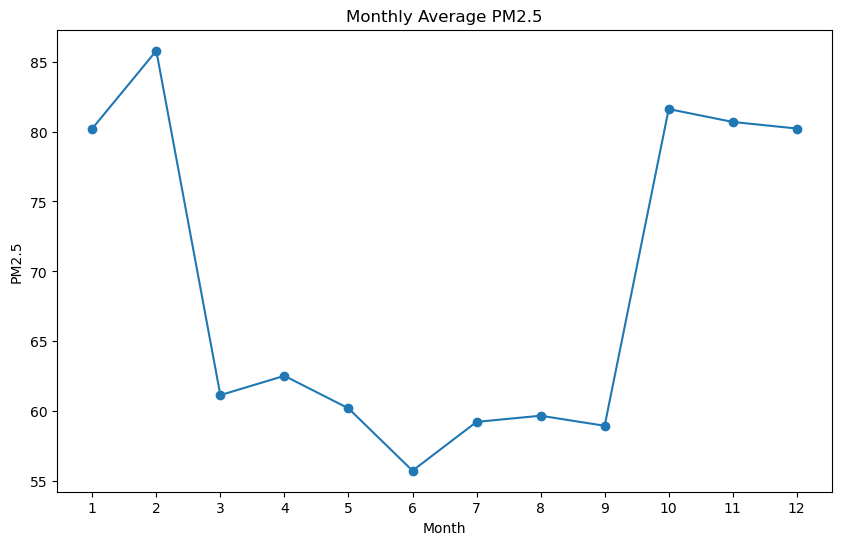

In [106]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_pollution.index,
    monthly_pollution["PM2_5"],
    marker="o"
)

plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.xticks(range(1, 13))

plt.show()

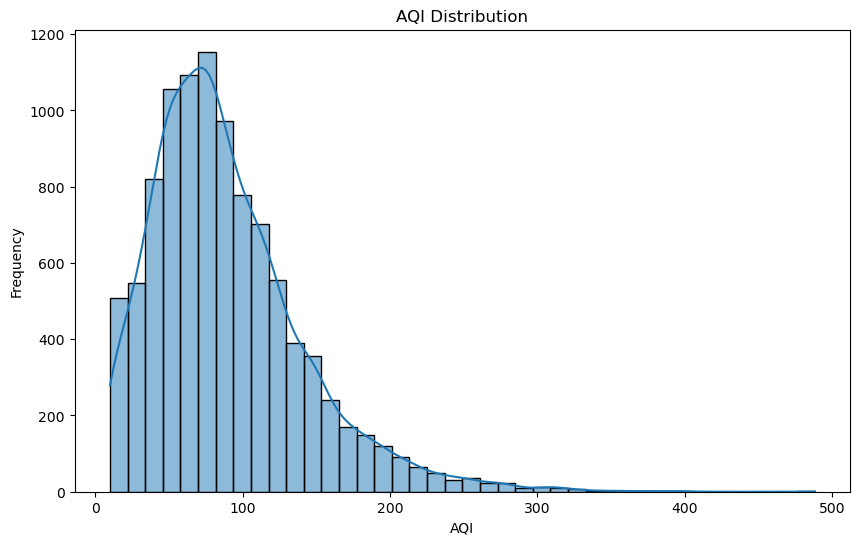

In [107]:
# AQI Distribution 
plt.figure(figsize=(10, 6))

sns.histplot(
    df["AQI"],
    bins=40,
    kde=True
)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

In [108]:
# Top 10 Worst AQI Days  
worst_days = (
    df.groupby(df["date_time"].dt.date)["AQI"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

worst_days

date_time
2025-12-19    170.000000
2024-10-06    167.500000
2025-02-09    161.250000
2023-02-13    158.714286
2024-12-29    156.666667
2025-12-10    155.500000
2023-02-24    155.166667
2023-03-08    154.285714
2025-12-13    152.700000
2023-03-09    150.000000
Name: AQI, dtype: float64

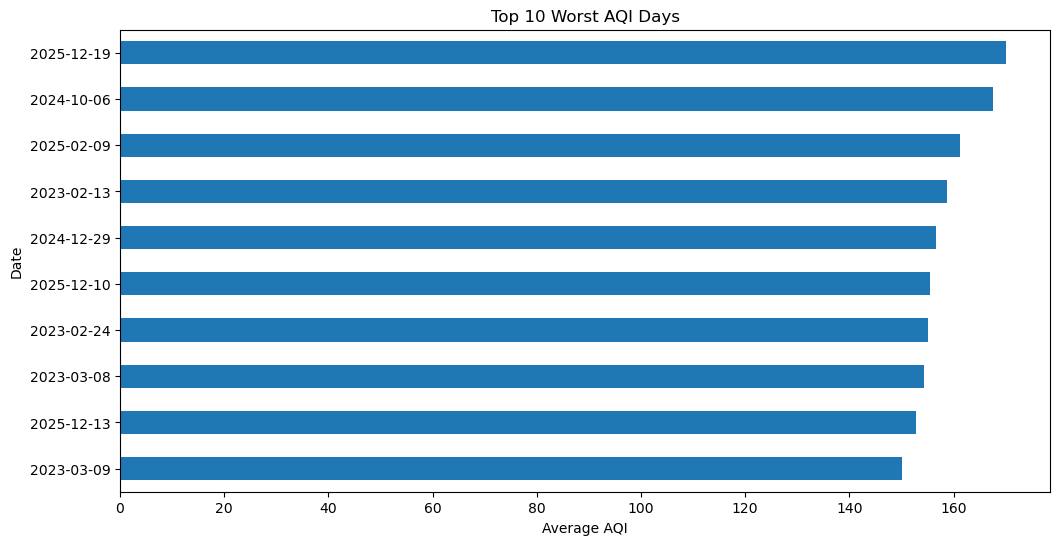

In [109]:
plt.figure(figsize=(12, 6))

worst_days.sort_values().plot(kind="barh")

plt.title("Top 10 Worst AQI Days")
plt.xlabel("Average AQI")
plt.ylabel("Date")

plt.show()

In [110]:
#  Summary Table 
summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Cities",
        "Total States",
        "Average AQI",
        "Maximum AQI",
        "Minimum AQI",
        "Average PM2.5",
        "Average PM10"
    ],
    
    "Value": [
        len(df),
        df["city"].nunique(),
        df["state"].nunique(),
        df["AQI"].mean(),
        df["AQI"].max(),
        df["AQI"].min(),
        df["PM2_5"].mean(),
        df["PM10"].mean()
    ]
})

summary

,Metric,Value
0,Total Records,9985.000000
1,Total Cities,20.000000
2,Total States,15.000000
3,Average AQI,89.060791
4,Maximum AQI,488.000000
5,Minimum AQI,10.000000
6,Average PM2.5,69.040406
7,Average PM10,135.608419
